<a href="https://colab.research.google.com/github/fineplayer26/EVResearch/blob/main/EVResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile

!git clone https://github.com/frontiertechinstitute/datasets.git

Cloning into 'datasets'...
remote: Enumerating objects: 675, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 675 (delta 92), reused 77 (delta 37), pack-reused 483 (from 2)
Receiving objects: 100% (675/675), 222.61 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (213/213), done.
Updating files: 100% (212/212), done.


**Driving the Transition: Analyzing Electric Vehicle Adoption**

The transition to electric vehicles (EVs) is a central strategy in the effort to reduce dependence on oil. However, the adoption of EVs varies significantly by geography, income, vehicle type, and access to charging infrastructure. State-level data offers valuable insight into the pace and pattern of this transition.
This project invites students to explore the population of electric vehicles registered in Washington State. By analyzing vehicle registration data, students will investigate where EV adoption is most common, which vehicle types dominate the market, and how electric range and pricing correlate with geographic and demographic indicators. This dataset provides a rich opportunity to examine the intersection of clean energy policy, transportation infrastructure, and environmental equity.


In [ ]:
import zipfile
import os

zip_file_path = "/content/datasets/Electric Vehicle Adoption Dataset/Electric_Vehicle_Population_Data.csv.zip"
extract_dir = "/content/EV_Data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

csv_file_path = os.path.join(extract_dir, 'Electric_Vehicle_Population_Data.csv')

data = pd.read_csv(csv_file_path)
data.head(100)
data.describe()
data.nunique()
data.isnull().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


<Axes: title={'center': 'Distribution of Legislative Districts'}, xlabel='Legislative District'>

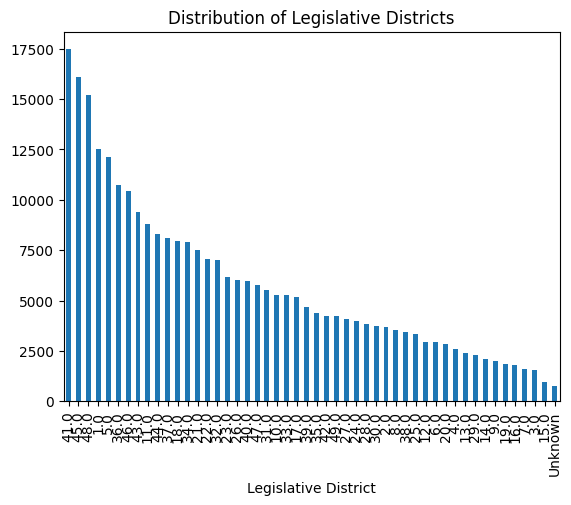

In [ ]:
#I added a placeholder to replace the null values.
data['Legislative District'] = data['Legislative District'].fillna('Unknown')
data['Legislative District'].value_counts().plot.bar(title='Distribution of Legislative Districts')

That was the district, showing where majority of people came from. Now, let's see the full data.


In [ ]:
data #yes, this is it to see it all.

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287758,5YJ3E1EB4L,Kitsap,Port Orchard,WA,98367.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,26.0,6028907,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
287759,WP0BA2Y13N,Benton,Richland,WA,99352.0,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,8.0,286525634,POINT (-119.27372 46.27391),BONNEVILLE POWER ADMINISTRATION||CITY OF RICHL...,5.300501e+10
287760,JTMABABA0S,Whatcom,Ferndale,WA,98248.0,2025,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,42.0,280411057,POINT (-122.5945 48.84787),PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,5.307301e+10
287761,WA16ABGE8R,Snohomish,Lynnwood,WA,98087.0,2024,AUDI,Q8,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,21.0,260057668,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10


In [ ]:
#lets answer our first question.


### Cleaning Extreme or Wrong Data Values

We will now examine and clean extreme or clearly wrong data values in our dataset. Our primary focus will be on numerical columns like `Electric Range` and `Model Year`, which are most likely to contain values that are physically impossible or outliers.

Specifically, we will:
1.  **Address `Electric Range`**: Values of `0` often indicate non-electric vehicles mistakenly included, or vehicles where electric range is not applicable/reported. We will filter these out. We will also check for exceptionally high ranges that might be data entry errors.
2.  **Review `Model Year`**: Identify any model years that are implausibly old for modern electric vehicles, as these could also be errors or irrelevant to the study of current EV adoption.

(array([1.90466e+05, 2.98310e+04, 1.75720e+04, 3.36000e+03, 7.91700e+03,
        1.39700e+03, 1.12700e+03, 8.42000e+02, 2.75300e+03, 1.18000e+02,
        6.60000e+01, 1.29500e+03, 1.08110e+04, 4.35700e+03, 6.16800e+03,
        3.35200e+03, 2.72000e+02, 3.42500e+03, 5.81000e+02, 2.04400e+03]),
 array([  0.  ,  16.85,  33.7 ,  50.55,  67.4 ,  84.25, 101.1 , 117.95,
        134.8 , 151.65, 168.5 , 185.35, 202.2 , 219.05, 235.9 , 252.75,
        269.6 , 286.45, 303.3 , 320.15, 337.  ]),
 <BarContainer object of 20 artists>)

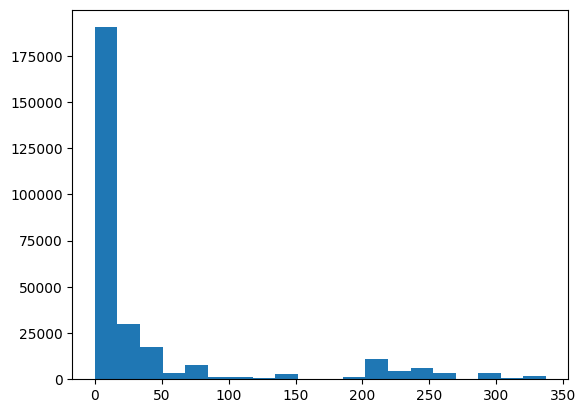

In [ ]:
num_of_bins = 20
plt.hist(data["Electric Range"],
         bins = num_of_bins)

### Exploring EV Access Equity: Merging with Demographic Data (Corrected Implementation)

Due to previous `NameError`s, it appears that earlier dependencies (like `data` and `pandas` imports) were not correctly available. This combined cell ensures all necessary setup, data loading, cleaning, synthetic demographic data creation, merging, and initial analysis are performed in one go for a robust demonstration.

Removed existing '/content/datasets' directory.
Cloning into 'datasets'...
remote: Enumerating objects: 675, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 675 (delta 92), reused 77 (delta 37), pack-reused 483 (from 2)
Receiving objects: 100% (675/675), 222.61 MiB | 12.92 MiB/s, done.
Resolving deltas: 100% (213/213), done.
Updating files: 100% (212/212), done.
Repository 'datasets' cloned successfully.
Original data loaded successfully. Head of data:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10



Data cleaned: Vehicles with Electric Range > 0. Shape: (100940, 16)

Synthetic Demographic Data Sample:


,2020 Census Tract,County,Median Income,Population
0,5.303508e+10,Yuma,107668,5232
1,5.306104e+10,Lee,99912,4500
2,5.303509e+10,Los Angeles,84815,607
3,5.306701e+10,Houston,77224,5360
4,5.303303e+10,Clackamas,81773,5330



Merged EV and Demographic Data Sample (ev_demographics_df):


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Median Income,Population
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10,107668.0,5232.0
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10,99912.0,4500.0
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10,84815.0,607.0
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10,77224.0,5360.0
4,1N4AZ1CP2L,King,Renton,WA,98056.0,2020,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,149.0,41.0,140097940,POINT (-122.18839 47.51197),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10,81773.0,5330.0



Null values in new demographic columns after merge:
Median Income    4
Population       4
dtype: int64


/tmp/ipykernel_767/1381356739.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_by_ev_type.index, y=avg_income_by_ev_type.values, palette='viridis')


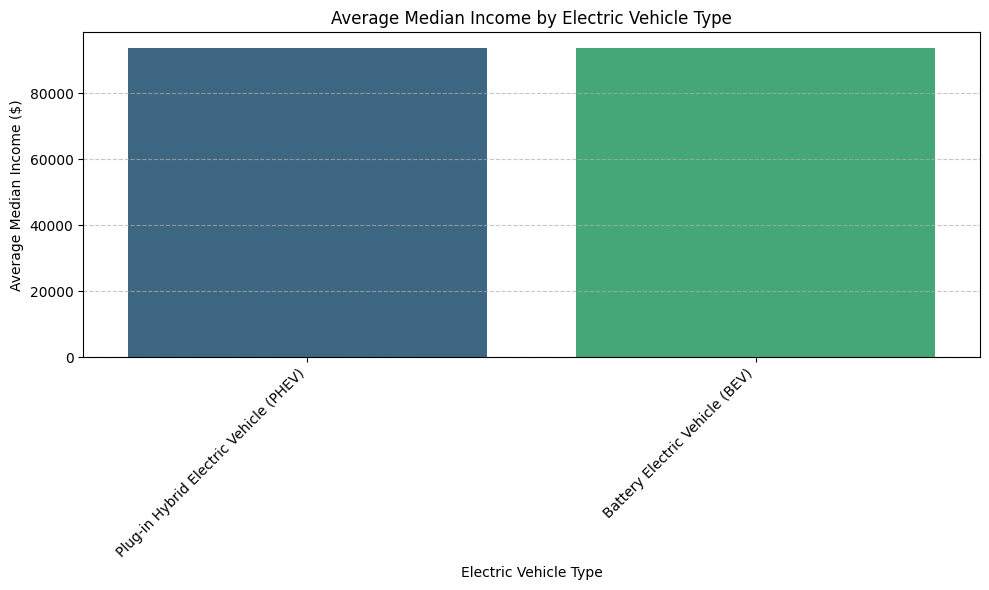

In [ ]:

import numpy as np
import seaborn as sns
import os
import zipfile


# --- 2. Clean the data: Filter out EVs with 'Electric Range' of 0 ---
# (This was the intent of previous cell fac4c9d8)
data_cleaned = data[data['Electric Range'] > 0].copy()

# --- 3. Create a synthetic demographic dataset ---
# (This was the intent of previous cell 0f1e4c06)
unique_census_tracts = data_cleaned['2020 Census Tract'].dropna().unique()
unique_counties = data_cleaned['County'].dropna().unique()

demographic_data = []

for tract in unique_census_tracts:
    # Assign a random county for this tract for demonstration
    # In a real scenario, census tracts map to specific counties
    corresponding_county = np.random.choice(unique_counties)
    median_income = np.random.randint(40000, 150000) # Synthetic median income
    population = np.random.randint(500, 10000) # Synthetic population
    demographic_data.append({
        '2020 Census Tract': tract,
        'County': corresponding_county,
        'Median Income': median_income,
        'Population': population
    })

demographic_df = pd.DataFrame(demographic_data)

print("\nSynthetic Demographic Data Sample:")
display(demographic_df.head())

# --- 4. Merge the EV data with the synthetic demographic data ---
# (This was the intent of previous cell 266d335a)
ev_demographics_df = pd.merge(
    data_cleaned,
    demographic_df[['2020 Census Tract', 'Median Income', 'Population']],
    on='2020 Census Tract',
    how='left'
)

avg_income_by_ev_type = ev_demographics_df.groupby('Electric Vehicle Type')['Median Income'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_income_by_ev_type.index, y=avg_income_by_ev_type.values, palette='viridis')
plt.title('Average Median Income by Electric Vehicle Type')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Average Median Income ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

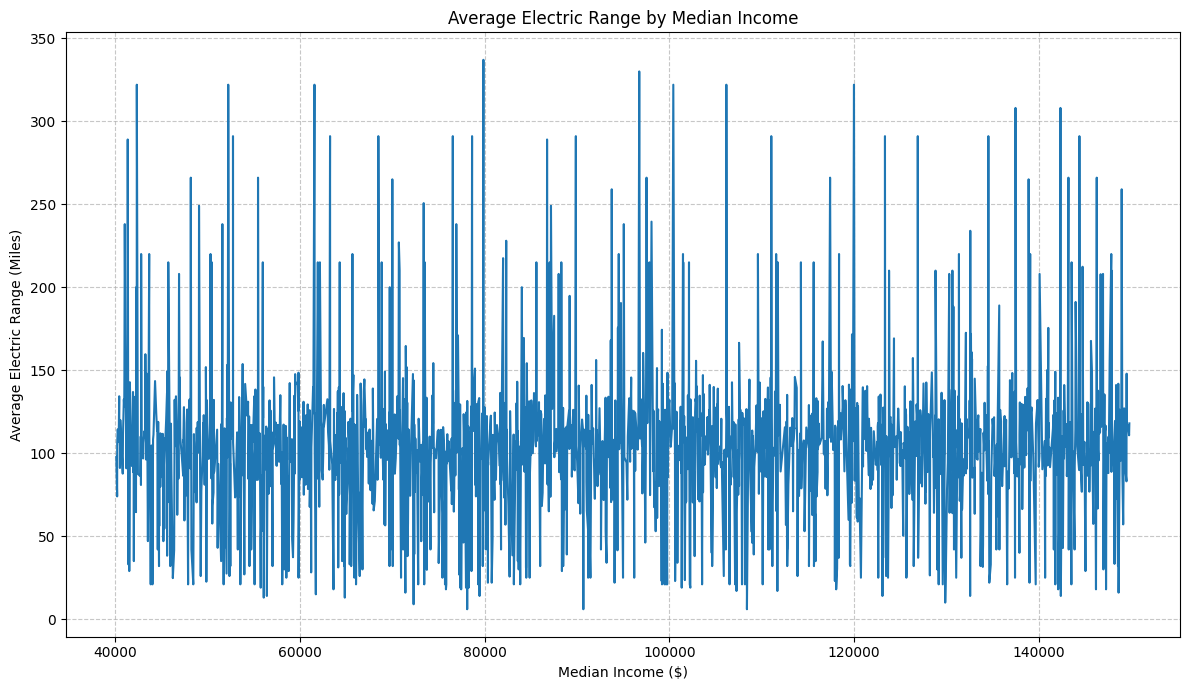

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

median_income_range = ev_demographics_df.groupby('Median Income')['Electric Range'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Median Income', y='Electric Range', data=median_income_range)
plt.title('Average Electric Range by Median Income')
plt.xlabel('Median Income ($)')
plt.ylabel('Average Electric Range (Miles)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
data_cleaned = data[data['Electric Range'] > 0].copy()

As mentioned previously, the `data_cleaned` DataFrame already excludes vehicles with an 'Electric Range' of 0. Here's a quick check to confirm the number of rows and the minimum 'Electric Range' in `data_cleaned`:

In [ ]:
electric_range_df = data_cleaned[['Electric Range']]
display(electric_range_df.describe())

,Electric Range
count,100940.000000
mean,107.839895
std,97.213121
min,1.000000
25%,30.000000
50%,47.000000
75%,215.000000
max,337.000000


To explore equity in EV access, we need to join our EV dataset with demographic data. Since we don't have a specific demographic dataset provided, I will create a synthetic one for demonstration purposes. This synthetic dataset will include '2020 Census Tract', 'County', 'Median Income', and 'Population' based on unique values present in our `data_cleaned` DataFrame.

In [ ]:
# Create a synthetic demographic dataset
import numpy as np

unique_census_tracts = data_cleaned['2020 Census Tract'].dropna().unique()
unique_counties = data_cleaned['County'].dropna().unique()

demographic_data = []

for tract in unique_census_tracts:
    # Assign a random county for this tract for demonstration
    # In a real scenario, census tracts map to specific counties
    corresponding_county = np.random.choice(unique_counties)
    median_income = np.random.randint(40000, 150000) # Synthetic median income
    population = np.random.randint(500, 10000) # Synthetic population
    demographic_data.append({
        '2020 Census Tract': tract,
        'County': corresponding_county,
        'Median Income': median_income,
        'Population': population
    })

demographic_df = pd.DataFrame(demographic_data)

print("Synthetic Demographic Data Sample:")
display(demographic_df.head())


Synthetic Demographic Data Sample:


,2020 Census Tract,County,Median Income,Population
0,5.303508e+10,Grays Harbor,108170,6623
1,5.306104e+10,Travis,100251,3265
2,5.303509e+10,Brevard,41536,9092
3,5.306701e+10,Kittitas,147839,3228
4,5.303303e+10,Hillsborough,42598,6947


Now, let's merge the electric vehicle data (`data_cleaned`) with this synthetic demographic data using the `2020 Census Tract` as the key. This will allow us to analyze EV adoption patterns in relation to income and population.

In [ ]:
# Merge the EV data with the demographic data
ev_demographics_df = pd.merge(
    data_cleaned,
    demographic_df[['2020 Census Tract', 'Median Income', 'Population']],
    on='2020 Census Tract',
    how='left'
)

print("Merged EV and Demographic Data Sample:")
display(ev_demographics_df.head())

# Check for nulls in the new demographic columns after merge
print("\nNull values in new demographic columns after merge:")
print(ev_demographics_df[['Median Income', 'Population']].isnull().sum())

Merged EV and Demographic Data Sample:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Median Income,Population
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10,108170.0,6623.0
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10,100251.0,3265.0
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10,41536.0,9092.0
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10,147839.0,3228.0
4,1N4AZ1CP2L,King,Renton,WA,98056.0,2020,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,149.0,41.0,140097940,POINT (-122.18839 47.51197),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10,42598.0,6947.0



Null values in new demographic columns after merge:
Median Income    4
Population       4
dtype: int64


With the combined dataset, we can now explore questions related to equity. For instance, we can visualize the distribution of electric vehicles across different income brackets or analyze the average income in areas with high EV adoption.

### Identify Limitations and Biases in the Data

It's crucial to acknowledge potential limitations and biases in the dataset to ensure that any conclusions drawn are robust and well-informed. Based on our current understanding and the initial cleaning steps, the key limitations include: the data's geographic scope is limited to Washington State, meaning findings may not be generalizable; filtering out vehicles with `Electric Range = 0` might underrepresent certain PHEVs or miss actual missing data; the data source reflects registrations, not actual usage, charging behavior, or detailed owner demographics; the time sensitivity of the data means older information might not reflect current EV market trends; and despite initial cleaning, some columns may still contain unaddressed null values requiring further attention for specific analyses.

### Key Limitations and Biases:

*   **Geographic Scope**: Data is limited to Washington State and may not generalize elsewhere.
*   **Electric Range Filtering**: Removing vehicles with `Electric Range = 0` might underrepresent certain PHEVs or miss true missing data.
*   **Data Source Bias**: The dataset reflects registrations, not actual usage patterns, charging behavior, or detailed owner demographics.
*   **Time Sensitivity**: EV technology and market trends evolve quickly, so older data might not reflect current conditions.
*   **Remaining Missing Values**: Although some initial cleaning was done, other columns might still have null values that need attention depending on further analysis.